In [1]:
#!pip install transformers wandb pandas datasets accelerate tyro matplotlib

  Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl.metadata (5.8 kB)
  Using cached contourpy-1.1.1-cp38-cp38-win_amd64.whl.metadata (5.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-10.4.0-cp38-cp38-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl.metadata (5.1 kB)
Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl (7.5 MB)
Using cached contourpy-1.1.1-cp38-cp38-win_amd64.whl (477 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 20.1 MB/s eta 0:00:00
Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl (55 kB)
Using cached pillow-10.4.0-cp38-cp38-win_amd64.whl (2.6 MB)
Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

In [3]:
# Load GPT‑2 model and tokenizer
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

In [4]:
# Set up reward models
# Distilled BERT classifier for sentiment analysis (using a fine‑tuned SST‑2 model)
distilled_bert_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1  # Ensures usage on CPU
)


In [5]:
# Zero‑shot classifier using facebook/bart-large-mnli
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1
)

In [6]:
def compute_reward_from_distilled_bert(text):
    # Assume that a "POSITIVE" sentiment reflects better output.
    results = distilled_bert_classifier(text)
    for res in results:
        if res['label'] == "POSITIVE":
            return res['score']
    return 0.0

def compute_reward_from_zero_shot(text, target_label="helpful"):
    results = zero_shot_classifier(text, candidate_labels=[target_label, "not helpful"])
    for label, score in zip(results["labels"], results["scores"]):
        if label == target_label:
            return score
    return 0.0

def reward_function(text):
    # Combine the rewards from both models (simple average)
    reward_bert = compute_reward_from_distilled_bert(text)
    reward_zero_shot = compute_reward_from_zero_shot(text, target_label="helpful")
    return (reward_bert + reward_zero_shot) / 2.0

def compute_log_probs(model, inputs):
    # Use model loss as a proxy for log probabilities (for demonstration)
    outputs = model(inputs, labels=inputs)
    return -outputs.loss

def keyword_reward(text, keywords=["fertilizer", "irrigation", "crop"]):
    score = 0
    text_lower = text.lower()
    for word in keywords:
        if word in text_lower:
            score += 0.33  # Increment the score for each keyword found
    return score

In [8]:
from datasets import load_dataset
import random

# Load agriculture dataset
dataset = load_dataset("Mahesh2841/Agriculture", split="train")
dataset = dataset.shuffle(seed=42)  # Shuffle for randomness

In [9]:
# Function to get a training sample
def get_training_sample():
    sample = random.choice(dataset)  # Pick a random example
    instruction = sample["instruction"]
    input_text = sample["input"]
    expected_response = sample["response"]
    
    # Combine instruction and input as the prompt
    prompt = f"{input_text}"
    
    return prompt, expected_response


In [10]:
# Set up optimizer and training parameters
optimizer = torch.optim.Adam(gpt2_model.parameters(), lr=5e-5)
num_epochs = 5
reward_history = []
prompt, expected_response = get_training_sample()
for epoch in range(num_epochs):
    #prompt = "Agricultural extension tip: What are the best practices for improving soil quality ?"
  # Example prompt for an agricultural extension agent
    inputs = gpt2_tokenizer.encode_plus(
    prompt,
    return_tensors='pt',
    padding=True,
    truncation=True
    )
    # Generate text with GPT‑2 (using a shorter max_length for faster CPU inference)
    generated_ids = gpt2_model.generate(
        inputs["input_ids"], 
        attention_mask=inputs["attention_mask"],
        max_length=80,
        do_sample=True,
        top_p=0.95,pad_token_id=gpt2_tokenizer.eos_token_id
    )
    generated_text = gpt2_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    
    # Compute reward from the generated text using our reward models
    reward = reward_function(generated_text)
    reward_history.append(reward)
    
    # Compute log probabilities for gradient update
    log_probs = compute_log_probs(gpt2_model, generated_ids)
    loss = -reward * log_probs  # Negative for gradient ascent style update
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Reward: {reward:.4f}")
    print(f"Generated Text: {generated_text}\n")

Epoch 1/5
Reward: 0.4954
Generated Text: how does dormancy affects seed germination. Seed germination rates for seedling plants depend on the species of the crop that is grown, the type of soil, and the climate. Seed germination rates for a particular plant depend on the climate and soil conditions. For soil-dependent plants like squash, for example, the best soil for seedlings depends on the type of soil (soil-

Epoch 2/5
Reward: 0.9676
Generated Text: how does dormancy affects seed germination.

Gastrointestinal

Seed germination is a key to improving your health and your health and well-being, according to the European Union.

Cultivating germination through seed quality, quality food and water quality

Seed quality is essential for healthy seeds to germinate and flourish in the soil.



Epoch 3/5
Reward: 0.9929
Generated Text: how does dormancy affects seed germination. The fact that the amount of nutrients is lower in warmer air tends to boost the seed germination rate of insects.

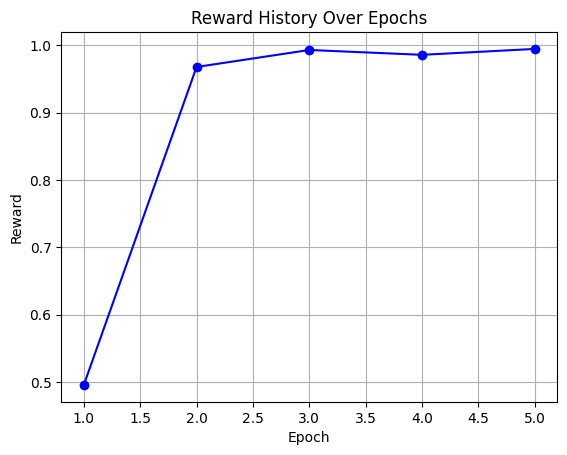

In [11]:
# Visualization: Plotting the reward history over epochs
plt.plot(range(1, num_epochs+1), reward_history, marker='o', color='blue')
plt.title("Reward History Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.grid(True)
plt.show()